In [1]:
#DAVID SANTIAGO PAEZ
#28/04/2026

# Customer Churn Prediction using Logistic Regression
DAVID SANTIAGO PAEZ

28/04/2026

Proyecto de Machine Learning para predecir abandono de clientes (Churn) en telecomunicaciones usando Regresión Logística.

In [4]:
# -----------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# -----------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [5]:
# -----------------------------------
# CARGA DEL DATASET
# -----------------------------------

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# -----------------------------------
# INFORMACIÓN GENERAL
# -----------------------------------

print(df.shape)
df.info()
df.isnull().sum()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# -----------------------------------
# LIMPIEZA DE DATOS
# -----------------------------------

# Convertir TotalCharges a número
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Eliminar nulos
df = df.dropna()

print(df.shape)

(7032, 21)


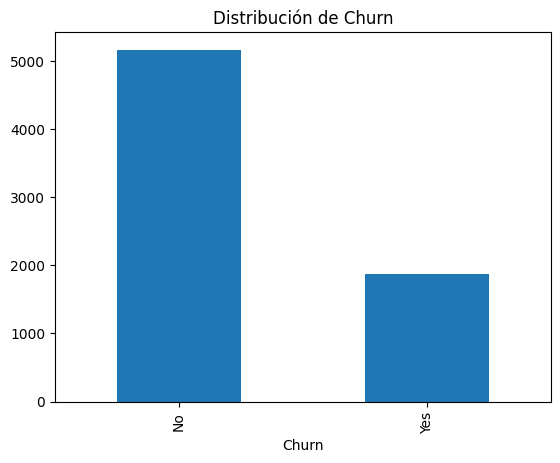

In [8]:
# -----------------------------------
# EDA RÁPIDO
# -----------------------------------

df["Churn"].value_counts()

df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.show()

In [9]:
# -----------------------------------
# ENCODING
# -----------------------------------

# Variable objetivo
y = df["Churn"].map({"Yes":1, "No":0})

# Variables predictoras
X = df.drop(["Churn", "customerID"], axis=1)

# Convertir texto a números
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [10]:
# -----------------------------------
# TRAIN / TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [11]:
# -----------------------------------
# SCALING
# -----------------------------------

X_train = X_train.astype(float)
X_test = X_test.astype(float)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# -----------------------------------
# MODELO
# -----------------------------------

modelo = LogisticRegression(
    max_iter=5000,
    solver="liblinear"
)

modelo.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, solver='liblinear')

In [13]:
# -----------------------------------
# MÉTRICAS
# -----------------------------------

y_pred = modelo.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8038379530916845
Precision: 0.6475903614457831
Recall   : 0.5748663101604278
F1 Score : 0.6090651558073654
[[916 117]
 [159 215]]


In [14]:
# -----------------------------------
# IMPORTANCIA DE VARIABLES
# -----------------------------------

coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_[0]
})

coef.sort_values(by="Coeficiente", ascending=False).head(10)

,Variable,Coeficiente
10,InternetService_Fiber optic,0.724660
3,TotalCharges,0.632460
21,StreamingTV_Yes,0.248959
23,StreamingMovies_Yes,0.235700
9,MultipleLines_Yes,0.214014
28,PaymentMethod_Electronic check,0.182510
26,PaperlessBilling_Yes,0.142627
0,SeniorCitizen,0.071051
17,DeviceProtection_Yes,0.068397
29,PaymentMethod_Mailed check,0.034014


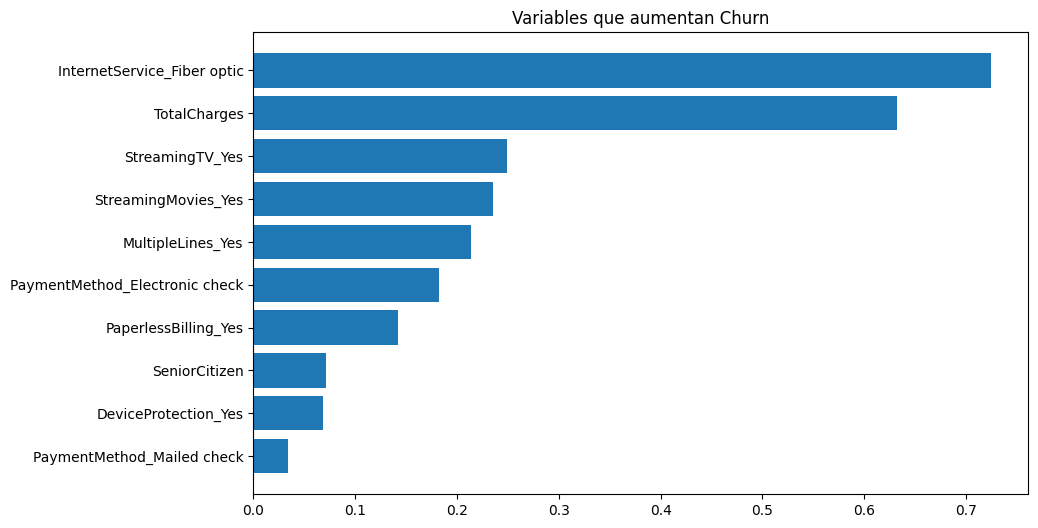

In [15]:
top = coef.sort_values(by="Coeficiente", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top["Variable"], top["Coeficiente"])
plt.gca().invert_yaxis()
plt.title("Variables que aumentan Churn")
plt.show()

# Conclusiones

- El modelo logró ~80% accuracy.
- Contratos largos reducen churn.
- Clientes nuevos presentan mayor riesgo.
- Fiber optic mostró alta relación con churn.
- Logistic Regression ofrece interpretabilidad y buen baseline.